<img src="https://www.unir.net/wp-content/uploads/2019/11/Unir_2021_logo.svg" width="240" height="240" align="right"/>

<center><h1>Técnicas de Inteligencia Artificial</header1></center>
<left><h1>Actividad 2. Trabajando con redes neuronales y Deep Learning</header1></left>

Presentado por: David Vicente Moya  <br>
Fecha: 22/05/2026

# Importación de librerias necesarias

# Parte I. Regresión

In [1]:
#Para esta actividad se importarán las siguientes librerías:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

## Cargar el Dataset

In [2]:
!pip install kagglehub

In [3]:
#Código para cargar el Dataset
#url = 'https://raw.githubusercontent.com/oscar-unir/TIA/main/datasets/car/Laboratorio_dataset_car.csv'

import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "imdb_top_1000.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows",
    file_path,
)

print("First 5 records:", df.head())

First 5 records:                                          Poster_Link  \
0  https://m.media-amazon.com/images/M/MV5BMDFkYT...   
1  https://m.media-amazon.com/images/M/MV5BM2MyNj...   
2  https://m.media-amazon.com/images/M/MV5BMTMxNT...   
3  https://m.media-amazon.com/images/M/MV5BMWMwMG...   
4  https://m.media-amazon.com/images/M/MV5BMWU4N2...   

               Series_Title Released_Year Certificate  Runtime  \
0  The Shawshank Redemption          1994           A  142 min   
1             The Godfather          1972           A  175 min   
2           The Dark Knight          2008          UA  152 min   
3    The Godfather: Part II          1974           A  202 min   
4              12 Angry Men          1957           U   96 min   

                  Genre  IMDB_Rating  \
0                 Drama          9.3   
1          Crime, Drama          9.2   
2  Action, Crime, Drama          9.0   
3          Crime, Drama          9.0   
4          Crime, Drama          9.0   

        

## Descripción de la fuente del Dataset

Los datos que vamos a utilizar contienen el top 1000 de películas mejor valoradas en IMDb. El dataset es de dominio público, y se encuentra disponible en la página de Kaggle: https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows?resource=download

- **`Poster_Link`**: Enlace al póster utilizado en IMDb
- **`Series_Title`**: Título de la película
- **`Released_Year`**: Año de estreno
- **`Certificate`**: Clasificación por edades
- **`Runtime`**: Duración en minutos
- **`Genre`**: Género(s) de la película, puede contener múltiples
- **`IMDB_Rating`**: Puntuación de la película en IMDb
- **`Overview`**: Sinopsis / resumen
- **`Meta_score`**: Puntuación de la crítica especializada (Metacritic)
- **`Director`**: Nombre del director
- **`Star1` / `Star2` / `Star3` / `Star4`**: Actores principales
- **`No_of_Votes`**: Número de votos recibidos
- **`Gross`**: Recaudación en taquilla

## Problema a resolver. 
El problema específico que queremos resolver es **predecir**, a partir de datos históricos, la recaudación de una película. Para esto no nos serán necesarios: *Poster_Link*, *Series_Title*, *Director* y *StarN*, ya que la mayoría son valores únicos que no aparecen más de una vez. Nuestra clase objetivo es **`Gross`**, el resto serán nuestras variables de entrada.

Un modelo que puede predecir cuánto va a recaudar una película tiene una utilidad práctica muy clara: productoras, distribuidoras e inversores podrían estimar el retorno económico esperado antes del estreno, ayudando a tomar decisiones sobre presupuesto, distribución y marketing. 

Las relaciones que tratamos de comprobar son, principalmente, cómo influyen factores como la puntuación en IMDb, el número de votos, la duración, el año de estreno, la clasificación por edades y el género cinematográfico en la recaudación final de una película. La hipótesis de partida es que películas con mayor número de votos, mejor puntuación y géneros de mayor audiencia tienden a recaudar más.

Para resolver este problema utilizaremos dos enfoques: una **red neuronal** entrenada con Keras sobre TensorFlow 2.0, y un **modelo de regresión clásico** (como Random Forest Regression) como referencia comparativa. Los resultados de ambos modelos se evaluarán mediante 
métricas estándar de regresión como el MAE, RMSE y R^2.

## Caracterización del Dataset


In [4]:
# Vamos a modificar un poco el dataset para poder analizar mejor sus valores (esto entra dentro de preprocesamiento  y limpieza de los datos)

# --- Runtime: eliminar " min" y convertir a numérico ---
df["Runtime"] = df["Runtime"].str.replace(" min", "").str.strip()
df["Runtime"] = pd.to_numeric(df["Runtime"], errors="coerce")

# --- Released_Year: convertir a numérico ---
df["Released_Year"] = pd.to_numeric(df["Released_Year"], errors="coerce")

# --- Gross: eliminar comas y convertir a numérico ---
df["Gross"] = df["Gross"].str.replace(",", "").str.strip()
df["Gross"] = pd.to_numeric(df["Gross"], errors="coerce")

# --- Genre: separar múltiples géneros y expandir en filas ---
# Primero convertimos la columna a lista de géneros
df["Genre"] = df["Genre"].str.split(", ")

# Explode: crea una fila por cada género, el original desaparece
df = df.explode("Genre").reset_index(drop=True)

# Verificar el resultado
print(f"Instancias tras el explode: {df.shape[0]}")
print(df[["Series_Title", "Genre"]].head(10))

Instancias tras el explode: 2541
               Series_Title   Genre
0  The Shawshank Redemption   Drama
1             The Godfather   Crime
2             The Godfather   Drama
3           The Dark Knight  Action
4           The Dark Knight   Crime
5           The Dark Knight   Drama
6    The Godfather: Part II   Crime
7    The Godfather: Part II   Drama
8              12 Angry Men   Crime
9              12 Angry Men   Drama


In [5]:
# Generamos estadísticas descriptivass de los datos
df.describe()

,Released_Year,Runtime,IMDB_Rating,Meta_score,No_of_Votes,Gross
count,2538.000000,2541.000000,2541.000000,2146.000000,2.541000e+03,2.109000e+03
mean,1991.622143,122.893349,7.944904,77.758155,2.785272e+05,7.234550e+07
std,23.393033,28.192994,0.272106,12.360541,3.231904e+05,1.144539e+08
min,1920.000000,45.000000,7.600000,28.000000,2.508800e+04,1.305000e+03
25%,1978.000000,102.000000,7.700000,70.000000,5.742800e+04,3.969893e+06
50%,1999.000000,119.000000,7.900000,79.000000,1.435250e+05,2.551452e+07
75%,2010.000000,137.000000,8.100000,87.000000,3.880890e+05,9.013519e+07
max,2020.000000,321.000000,9.300000,100.000000,2.343110e+06,9.366622e+08


In [6]:
# Vemos el número de instancias que tiene el set
df.shape

(2541, 16)

In [7]:
# Vemos qué tipos de variables contiene el dataset y qué valores no contienen nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2541 entries, 0 to 2540
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    2541 non-null   object 
 1   Series_Title   2541 non-null   object 
 2   Released_Year  2538 non-null   float64
 3   Certificate    2306 non-null   object 
 4   Runtime        2541 non-null   int64  
 5   Genre          2541 non-null   object 
 6   IMDB_Rating    2541 non-null   float64
 7   Overview       2541 non-null   object 
 8   Meta_score     2146 non-null   float64
 9   Director       2541 non-null   object 
 10  Star1          2541 non-null   object 
 11  Star2          2541 non-null   object 
 12  Star3          2541 non-null   object 
 13  Star4          2541 non-null   object 
 14  No_of_Votes    2541 non-null   int64  
 15  Gross          2109 non-null   float64
dtypes: float64(4), int64(2), object(10)
memory usage: 317.8+ KB


In [8]:
# Visualizamos el total de valores nulos de cada variable del dataset
df.isnull().sum()

Poster_Link        0
Series_Title       0
Released_Year      3
Certificate      235
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       395
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            432
dtype: int64

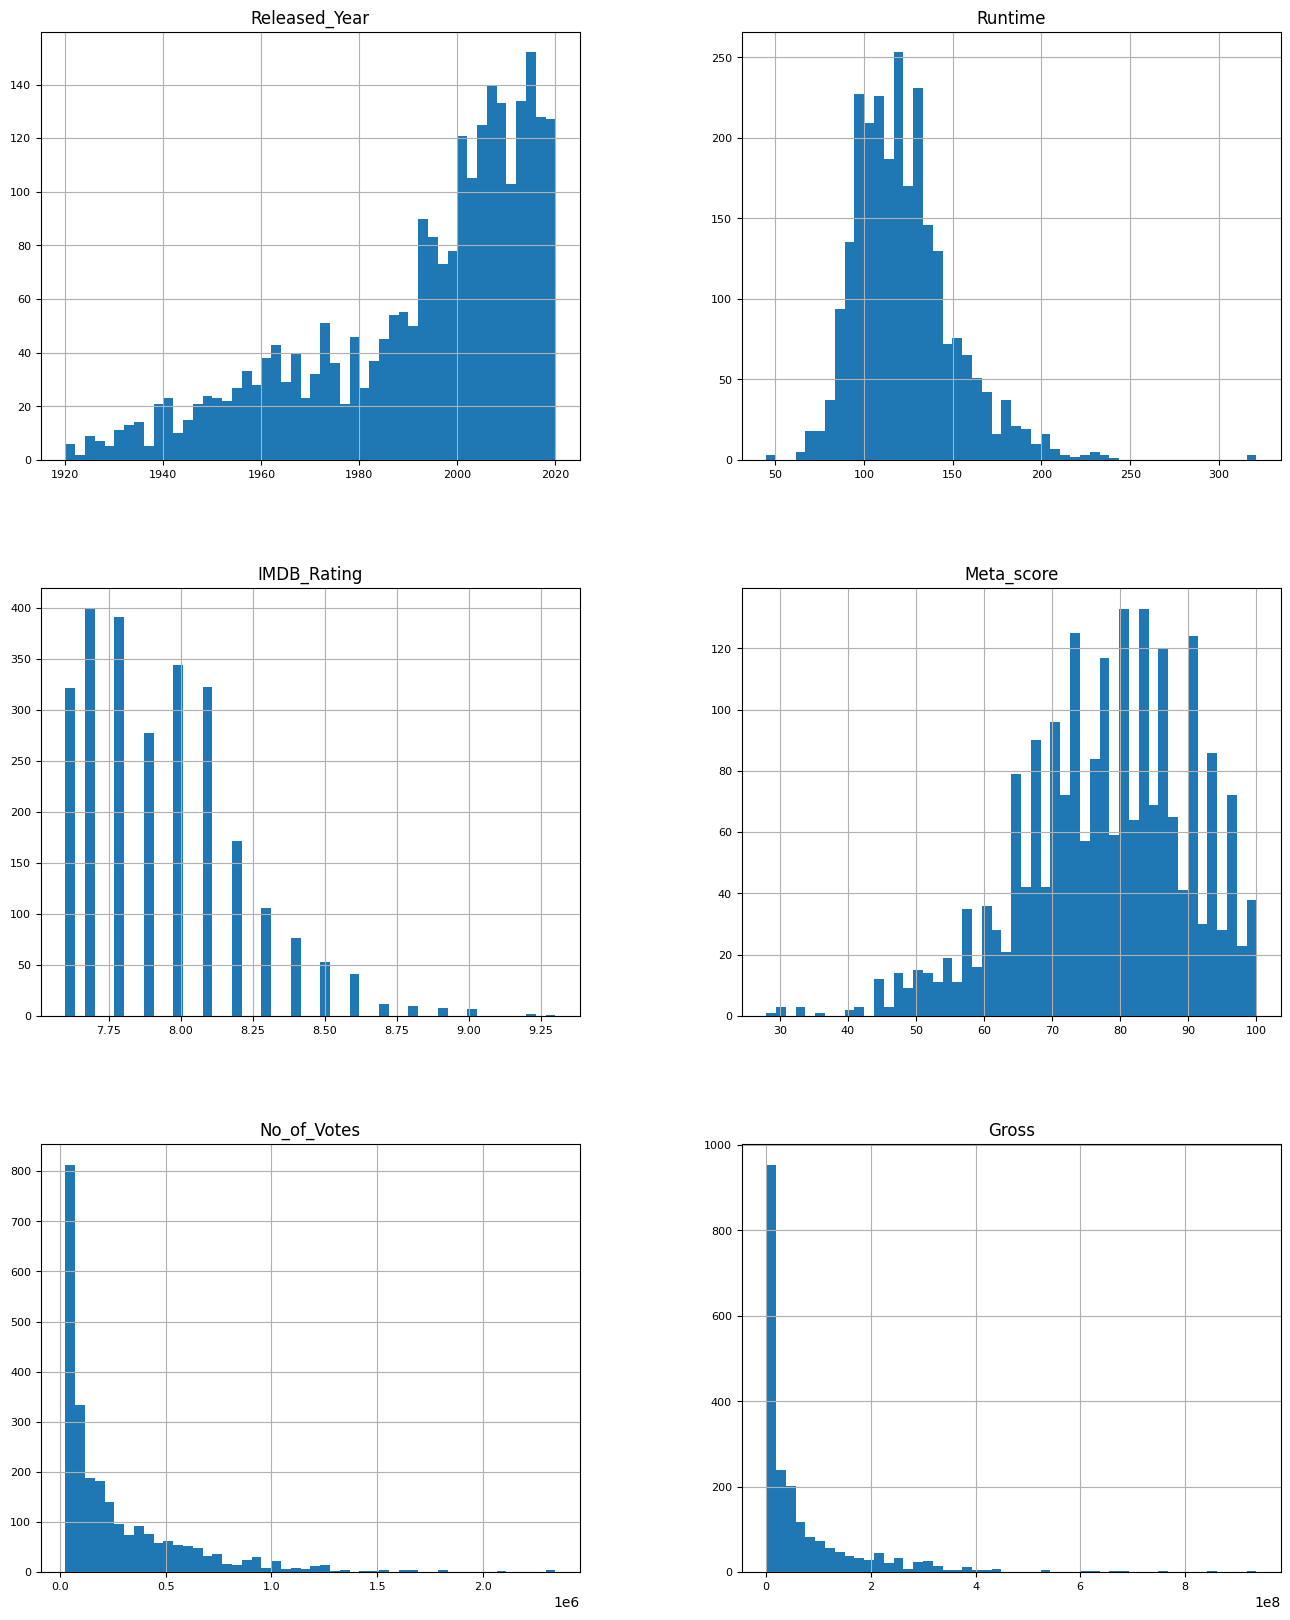

In [9]:
# Dibujamos los histogramas de las variables numéricas para conocer su distribución
df.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

[Text(0.5, 0, 'Released_Year'),
 Text(1.5, 0, 'Runtime'),
 Text(2.5, 0, 'IMDB_Rating'),
 Text(3.5, 0, 'Meta_score'),
 Text(4.5, 0, 'No_of_Votes'),
 Text(5.5, 0, 'Gross')]

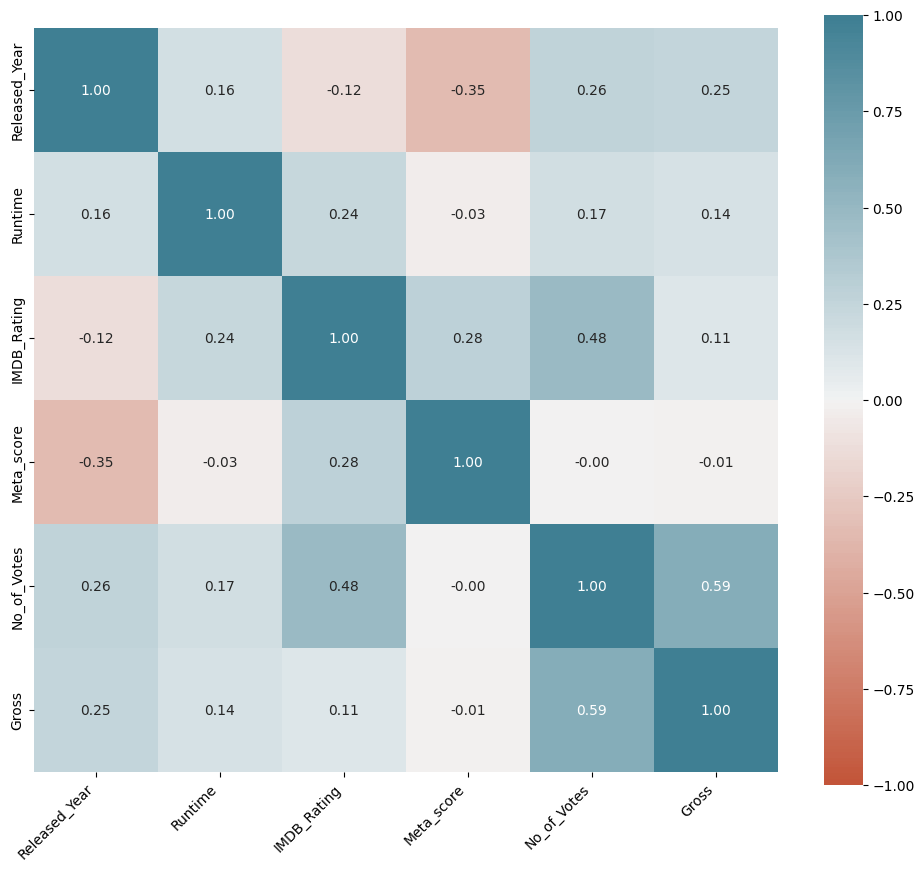

In [10]:
# Calculamos el coeficiente de correlación de Pearson
corr = df.corr(method = 'pearson', numeric_only = True)

# Hacemos un headpmap con tamaño ampliado, cuadrado, divergencia con colores y con anotaciones de 2 decimales
plt.figure(figsize=(12,10))
ax = sns.heatmap(
 corr,
 vmin=-1, vmax=1, center=0,
 cmap=sns.diverging_palette(20, 220, n=200),
 square=True, annot=True, fmt=".2f"
)

# Rotamos las etiquetas del eje horizontal
ax.set_xticklabels(
 ax.get_xticklabels(),
 rotation=45,
 horizontalalignment='right'
)

Estos datos nos muestran que hay una estrecha relación entre el éxito de una película, tiene gran recaudación, con el año de estreno (*0.25*) y número de votos recibidos (*0.59*) en la página de IMDb. esto podría estar relacionado en parte con un incremento de la población a lo largo de los años, cuanta más gente hay que pueda y quiera ver la película mayores serán los beneficios de la misma. Al aumentar el número de votos también aumenta la calificación final de IMDb (*0.48*), que a su vez afecta ligéramente de forma positiva a los ingresos (*0.11*). Coincidentemente, la puntuación recibida de la crítica profesional (*-0.01*) carece prácticamente de impacto en el éxito de la película. Por último, la películas de mayor duración también mejoran el resultado final (*0.14*) y afecta directamente la interacción de la audiencia (*0.17*), aunque no por mucho.

Como apunte final, destaca el efecto del año de estreno sobre la valoración final tanto de la audiencia en general de IMDb (*-0.12*) como de los críticos profesionales (*-0.35*). Es curioso ver como las películas más modernas reciben peor calificación. Esto podría apuntar a una inclinación por parte de la audiencia a valorar de mejor manera las películas más antiguas. Una hipótesis sería el efecto nostalgia que provoca que las personas valoren mejor las películas antiguas sobre las modernas.

## Preprocesamiento del dataset. Transformaciones previas necesarias para la modelación

In [11]:
# Eliminamos las variables que no aportan nada
cols_eliminar = [
    'Poster_Link',
    'Series_Title',
    'Overview',
    'Director',
    'Star1',
    'Star2',
    'Star3',
    'Star4',
]
df = df.drop(columns=cols_eliminar, errors='ignore')

In [12]:
# Nos deshacemos de los valores nulos
df["Certificate"] = df["Certificate"].fillna("UR") # UR = UnRated, carece de clasificación
df = df.dropna()

In [13]:
# Utilizamos one-hot encoding para el codificar tanto los géneros como la clasificación por edades 
df = pd.get_dummies(df, columns=["Certificate", "Genre"], prefix=["Certificate", "Genre"])

## División del dataset en datos de entrenamiento y datos de test 

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

In [15]:
# Separamos los datos en los conjuntos de entrenamiento y test
X, y = df.drop('Gross',axis=1),df['Gross']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # Utilizamos el 30% de los datos como test (test_size = 0.3)

In [16]:
# Vamos a usar el escalador MinMaxScaler que normalizará los valores entre 0 y 1
# Esto lo hacemos porque estamos usando one-hot encoding para genre y certificate
# de esta forma todos nuestros datos están en el mismo rango
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

## Propuesta de arquitectura de red neuronal

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

#Obtenemos el número de valores únicos de la variable objetivo
num_clases = len(np.unique(y))

# Diseñamos la arquitectura de la red neuronal
model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)), # Capa de entrada
    layers.Dense(32, activation='relu'),     # Primera capa con 32 neuronas y función de activación ReLu
    layers.Dense(16, activation='relu'),     # Segunda capa, 16 neurona y función de activación ReLu
    layers.Dense(8, activation='relu'),      # Tercera capa, 8 neuronas y función de activación ReLu
    layers.Dense(1)                          # Capa de salida, 1 neurona sin activación porque es regresión
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │           1,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,953 (7.63 KB)

 Trainable params: 1,953 (7.63 KB)

 Non-trainable params: 0 (0.00 B)

##  Ajuste de modelo de Regresión RNA

In [18]:
# Compilamos el modelo
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(0.001), # algoritmo de optimización
    loss='mse',       # para más opciones consultar: https://keras.io/api/losses/regression_losses/
    metrics=['mae', 'mse']   # Se ha utilizado mae para las métricas por representar mejor el resultado que mse
)

El algoritmo de optimización lo he sacado del ejempli de uso de TensorFlow: https://www.tensorflow.org/tutorials/keras/regression?hl=es-419#el_set_de_datos_de_mpg

In [19]:
# Entrenamos el modelo por 1000 ciclos con tamaño de muestra 32
history = model.fit(X_train, y_train, epochs=1000, batch_size=32, validation_split=0.2)

Epoch 1/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 20295447050452992.0000 - mae: 79727400.0000 - mse: 20295447050452992.0000 - val_loss: 23298082309406720.0000 - val_mae: 86915968.0000 - val_mse: 23298082309406720.0000
Epoch 2/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20295447050452992.0000 - mae: 79727392.0000 - mse: 20295447050452992.0000 - val_loss: 23298082309406720.0000 - val_mae: 86915968.0000 - val_mse: 23298082309406720.0000
Epoch 3/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20295444902969344.0000 - mae: 79727384.0000 - mse: 20295444902969344.0000 - val_loss: 23298080161923072.0000 - val_mae: 86915952.0000 - val_mse: 23298080161923072.0000
Epoch 4/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20295440608002048.0000 - mae: 79727376.0000 - mse: 20295440608002048.0000 - val_loss: 23298075866955776.0000 - val_mae: 86915944.0000 - val_mse: 23298075866955776.0000
Epoch 5/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20295440608002048.0000 - mae

## Evaluación de modelo RNA

### Visualice el progreso de entrenamiento del modelo y muestre las estadísticas de evaluación para los conjuntos de entrenamiento y validación.  

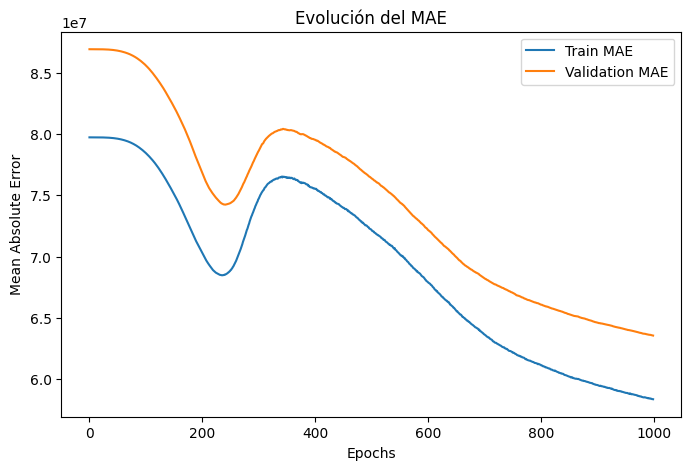

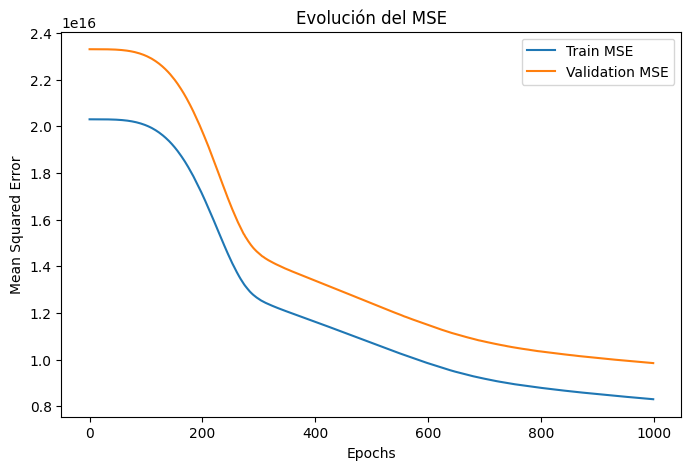

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.title('Evolución del MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

plt.show()



plt.figure(figsize=(8, 5))

plt.plot(history.history['mse'], label='Train MSE')
plt.plot(history.history['val_mse'], label='Validation MSE')

plt.title('Evolución del MSE')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()

plt.show()

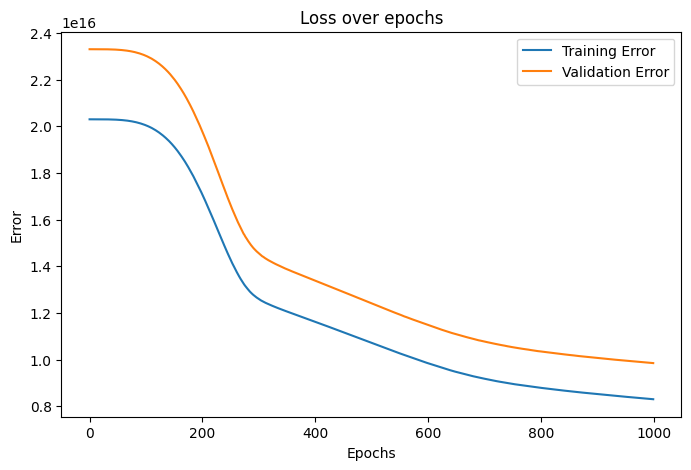

In [21]:
# Mostramos la gráfica con la evolución del error obtenido para los datos de entrenamiento y la validación a lo largo de los époch
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Error')
plt.plot(history.history['val_loss'], label='Validation Error')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.legend()

plt.show()

### Evalúe los resultados  para el conjunto de test.

In [22]:
# Realizamos la predicción con el modelo generado y los datos de Test
y_pred = model.predict(X_test).flatten()

mae_rn  = mean_absolute_error(y_test, y_pred)
rmse_rn = np.sqrt(mean_squared_error(y_test, y_pred))
r2_rn   = r2_score(y_test, y_pred)

print("RED NEURONAL")
print(f"MAE:  {mae_rn:,.2f}")
print(f"RMSE: {rmse_rn:,.2f}")
print(f"R²:   {r2_rn:.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
RED NEURONAL
MAE:  60,688,643.49
RMSE: 94,551,608.54
R²:   0.3132


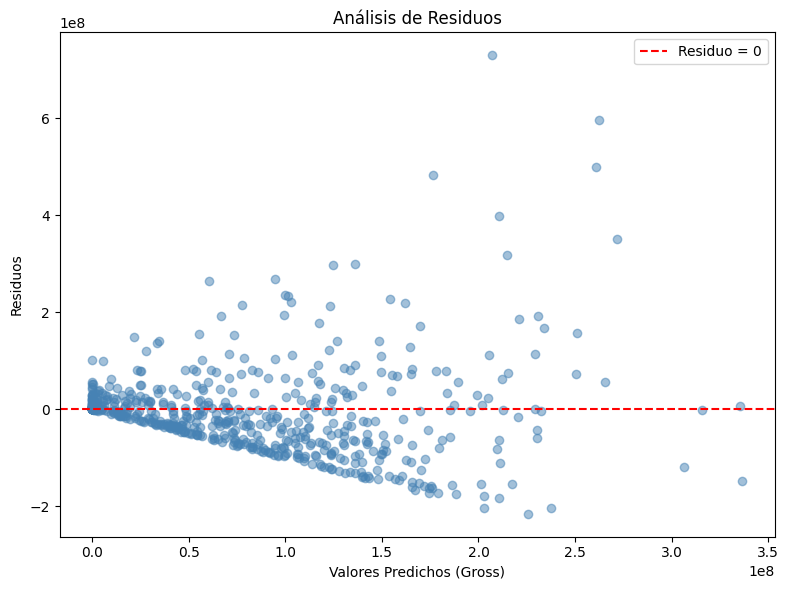

In [23]:
# Compararé los resultados predichos con los esperados mediante un gráfico de residuos
residuos = y_test - y_pred

# Construyo una gráfica de scatter
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuos, alpha=0.5, color="steelblue")
plt.axhline(y=0, color="red", linestyle="--", label="Residuo = 0")
plt.title("Análisis de Residuos")
plt.xlabel("Valores Predichos (Gross)")
plt.ylabel("Residuos")
plt.legend()
plt.tight_layout()
plt.show()

## Ajuste de modelos de Regresión alternativos

In [24]:
from sklearn.ensemble import RandomForestRegressor

# Defino el modelo Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,    # número de árboles
    max_depth=10,        # profundidad máxima de cada árbol
    min_samples_split=5, # mínimo de muestras para dividir un nodo
    min_samples_leaf=2,  # mínimo de muestras en cada hoja
    random_state=42      # semilla para reproducibilidad
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
y_pred_rf = rf_model.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("RANDOM FOREST REGRESSION")
print(f"MAE:  {mae_rf:,.2f}")
print(f"RMSE: {rmse_rf:,.2f}")
print(f"R²:   {r2_rf:.4f}")

RANDOM FOREST REGRESSION
MAE:  43,196,991.88
RMSE: 69,765,914.59
R²:   0.6261


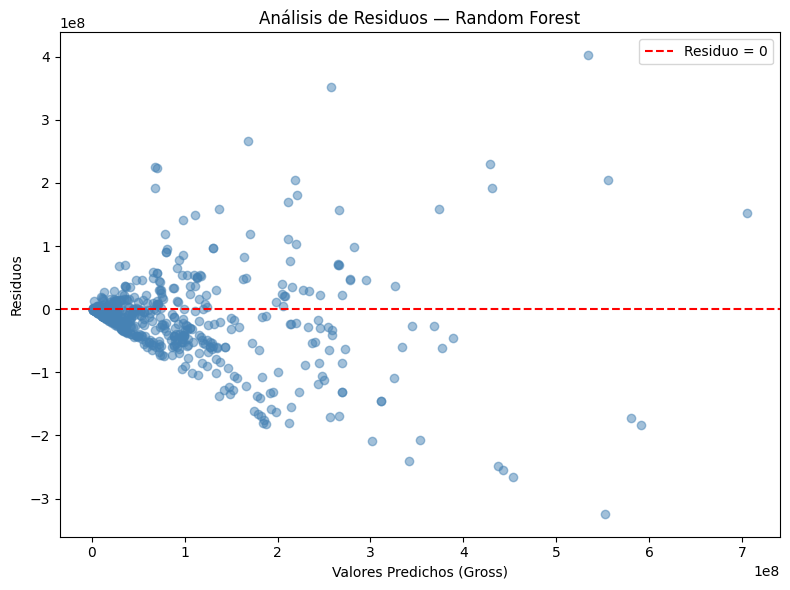

In [26]:
residuos_rf = y_test - y_pred_rf

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_rf, residuos_rf, alpha=0.5, color="steelblue")
plt.axhline(y=0, color="red", linestyle="--", label="Residuo = 0")
plt.title("Análisis de Residuos — Random Forest")
plt.xlabel("Valores Predichos (Gross)")
plt.ylabel("Residuos")
plt.legend()
plt.tight_layout()
plt.show()

## Comparación del desempeño de modelos

In [27]:
#Código para mostrar la comparación de métricas de desempeño de las dos propuestas en tabla
comparacion = pd.DataFrame({
    "Modelo": ["Red Neuronal", "Random Forest"],
    "MAE":    [mae_rn, mae_rf],
    "RMSE":   [rmse_rn, rmse_rf],
    "R²":     [r2_rn, r2_rf]
})

print(comparacion.to_string(index=False))

       Modelo          MAE         RMSE       R²
 Red Neuronal 6.068864e+07 9.455161e+07 0.313238
Random Forest 4.319699e+07 6.976591e+07 0.626100


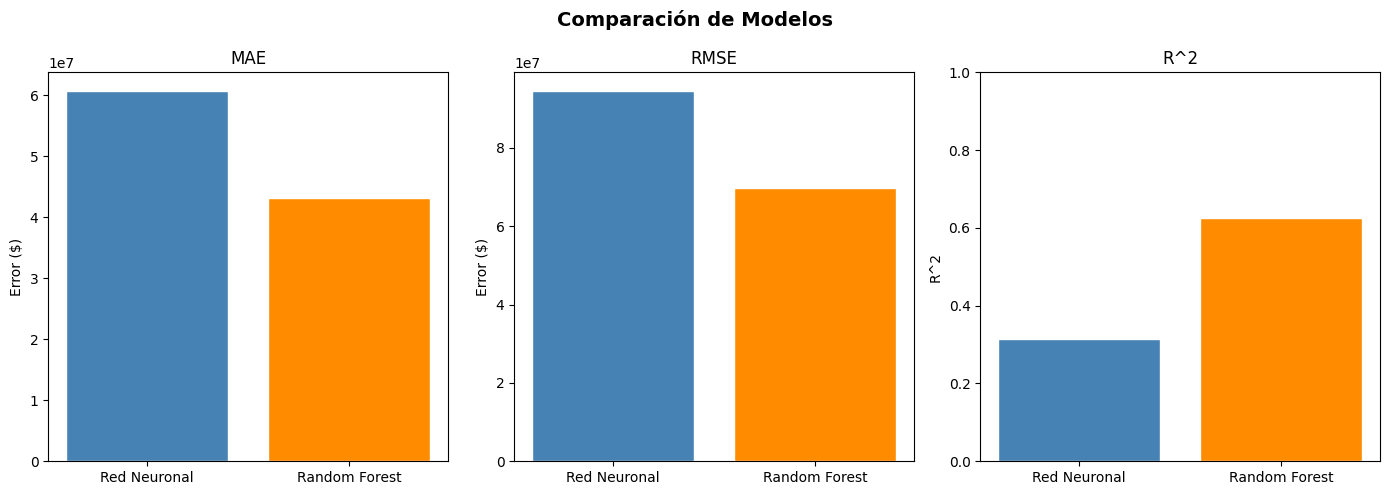

In [28]:
#Código para mostrar la comparación de métricas de desempeño de las dos propuestas en gráfica
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Comparación de Modelos", fontsize=14, fontweight="bold")

modelos = ["Red Neuronal", "Random Forest"]
colores = ["steelblue", "darkorange"]

# MAE
axes[0].bar(modelos, [mae_rn, mae_rf], color=colores, edgecolor="white")
axes[0].set_title("MAE")
axes[0].set_ylabel("Error ($)")

# RMSE
axes[1].bar(modelos, [rmse_rn, rmse_rf], color=colores, edgecolor="white")
axes[1].set_title("RMSE")
axes[1].set_ylabel("Error ($)")

# R^2
axes[2].bar(modelos, [r2_rn, r2_rf], color=colores, edgecolor="white")
axes[2].set_title("R^2")
axes[2].set_ylabel("R^2")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Discusión de los resultados obtenidos y argumentos sobre cómo se podrían mejorar de dichos resultados

La comparación entre los dos modelos muestra que el **Random Forest** supera a la **Red Neuronal** en todas las métricas evaluadas. En términos de error absoluto medio, el Random Forest comete un error promedio de *43,196,990\$*, frente a los *60,688,640$* de la red neuronal, lo que supone una mejora del *30%*. Esta diferencia se acentúa aún más en el RMSE, lo que indica que la red neuronal sufre más ante los valores extremos de recaudación. El dato más revelador es el R^2, donde el Random Forest explica el *62.61%* de la varianza de la recaudación frente al *31.32%* de la red neuronal. Esto sugiere que, para este dataset en particular, el Random Forest generaliza considerablemente mejor, probablemente debido al reducido tamaño del dataset , ya que las redes neuronales tienden a necesitar volúmenes de datos mayores para alcanzar su máximo potencial predictivo.

Los resultados de la red neuronal podrían mejorarse de varias formas. La más impactante sería disponer de un **dataset más grande**. Complementariamente, aplicar una **transformación logarítmica** sobre `Gross` reduciría el impacto de los outliers. Por último, incorporar técnicas como **Early Stopping** evitaría el sobreajuste durante el entrenamiento.